Testato con monai 1.5.2, torchvision 0.24, torchmetrics 1.8.2, matplotlib 3.10.8, torchinfo 1.8.0, tqdm 4.67.2, scikit-learn 1.8.0
Esempio di rete U-Net per la segmentazione di immagini.

# Simple U-NET Test 3 - Notebook 6.6

In [1]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # display cycle progress

# Import torch
import torch
from torch import nn
from torch.utils.data import Subset, random_split
from torchmetrics import Accuracy
from torchinfo import summary

# import monai functions
import monai
from monai.metrics import compute_confusion_matrix_metric, get_confusion_matrix
from monai.transforms import RandShiftIntensityd,Activations, SqueezeDimd,AsDiscrete, EnsureTyped,EnsureChannelFirstd,Compose, SqueezeDim,LoadImaged, DataStats,RepeatChanneld,RandRotate90d, Resized, ScaleIntensityd
from monai.transforms import LoadImage,EnsureChannelFirst,ScaleIntensity,RandRotate,RandFlip,RandZoom


C:\Users\ippop\anaconda3\envs\jupyter\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
# Exercises require PyTorch > 1.10.0
print(torch.__version__)
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.8.0


'cpu'

In [3]:
# define main training parameters
SEED = 42
BATCH_SIZE = 8
LEARNING_RATE = 0.001

Utilizziamo il set di immagini in TEST3, che include due cartelle. La cartella images contiene le immagini da segmentare mentre la cartella masks contiene le maschere della segmentazione "corretta" (Reference). Ogni coppia è formata da una immagine binaria 32x32 che descrive una croce ruotata in modo casuale (ground truth per la segmentazione) e la stessa immagine a cui è stato addizionato rumore gaussiano, che rappresenta l’immagine a livelli di grigio da segmentare. 

In [4]:
# image data path. Adapt to your environment
image_path = r"C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST3" 

In [8]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images \
          in '{dirpath}'.")       

walk_through_dir(image_path)  # show data structure

There are 2 directories and 0 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST3'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST3\Images'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST3\masks'.


Nei task di classificazione abbiamo coppie immagine/label, dove le label sono stringhe che vengono lette dal nome della cartella. Nei task di segmentazione abbiamo coppie immagine/maschera, dove la maschera è anch'essa una immagine. Qui supponiamo che l'ordine delle immagini e delle maschere nelle cartelle sia lo stesso. In altri casi può essere necessario identificare le corrispondenze, tipicamente attraverso la creazione di un foglio di calcolo.  

Lo facciamo "a mano" ma probabilmente esiste qualcosa di più automatico 

In [9]:
# list of folders
folders = []
for dir_path, dirnames, filenames in os.walk(image_path):
    for d in dirnames:
        folders.append(d)
        
# list of images and masks
Images = []
for dir_path, dirnames, filenames in os.walk(os.sep.join([image_path,folders[0]])):
    for f in filenames:
        Images.append(os.sep.join([dir_path,f]))
Masks = []
for dir_path, dirnames, filenames in os.walk(os.sep.join([image_path,folders[1]])):
    for f in filenames:
        Masks.append(os.sep.join([dir_path,f]))

Creiamo la lista delle coppie immagine/maschera 

In [10]:
# list of image/mask files pairs
all_files = [{"img": img, "mask": mask} for img, mask in zip(Images, Masks)]

Creiamo le funzioni per l'import delle immagini e delle maschere. Tutte le operazioni devono essere fatte sia sull'immagine che sulla maschera per mantenere la congruenza tra le due. Qui carichiamo le immagini, ci assicuriamo che il formato sia corretto (canali x dx x dy e non dx x dy x canali), normalizziamo tra 0 e 1 ed interpoliamo alla dimensione desiderata. Nel training possiamo aggiungere il data augmentation on-the-fly,  

In [11]:
# define transforms for data loading
# train transform (can include image augmentation)
train_transform = Compose(
    [
        LoadImaged(keys=["img", "mask"]),          # load image/mask (single channel images) 
        EnsureChannelFirstd(keys=["img", "mask"]), # add channel
        ScaleIntensityd(keys=["img", "mask"]),     # normalize intensity  
        #RandRotate90d(keys=["img", "mask"], prob=0.5, spatial_axes=[0, 1]),
        Resized(keys=["img", "mask"], spatial_size=(128, 128)),  # resize image and mask
    ]
)
# val/test transform (no image augmentation)
val_transform = Compose(
    [
        LoadImaged(keys=["img", "mask"]), # load image/mask (single channel images)
        EnsureChannelFirstd(keys=["img", "mask"]), # add channel
        ScaleIntensityd(keys=["img", "mask"]),
        Resized(keys=["img", "mask"], spatial_size=(128, 128)),  # resize image and mask
    ]
)

Creiamo un dataset monai e controlliamo sia corretto. Un elemento del dataset deve essere una tuple di due elementi (batch_size, numero canali, dimX, dimY). Qui dovremmo avere un singolo canale. 

In [13]:
# create monai datast
from monai.data import DataLoader, Dataset,list_data_collate, decollate_batch

# monai dataset from files (validation transform)
all_data = Dataset(all_files,transform=val_transform)  

# check Dataset (an image should be (batch_size,channels,dx,dy))
check_ds = Dataset(data=all_files, transform=train_transform)
check_loader = DataLoader(check_ds, batch_size=2, collate_fn=list_data_collate)
check_data = monai.utils.misc.first(check_loader)
print(check_data["img"].shape, check_data["mask"].shape)

torch.Size([2, 1, 128, 128]) torch.Size([2, 1, 128, 128])


Ci creiamo train, validation e test set. Quando abbiamo creato il dataset globale gli abbiamo assegnato val_transform, quindi al train dobbimo assegnare train_transform 

In [15]:
# split data set in train, validation, and test
test_perc  = 0.10 # percentage of data in the test set
val_perc  = test_perc # percentage of data in validation set
N_test = int(np.ceil(len(all_data)*test_perc)) # images in test set
N_val = int(np.ceil((len(all_data)-N_test)*val_perc)) # images in validation set
N_train=len(all_data)-N_val-N_test # images in training set

# split whole monai database in training, validation, and test set
train_dataset, val_dataset, test_dataset = random_split(all_data, [N_train, N_val, N_test]) # all daset take the same transforma
train_dataset.transform=train_transform  # define training transform 

Creiamo i dataloader

In [16]:
# create dataloaders batches 
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE,shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=1)
test_dataloader = DataLoader(test_dataset, batch_size=1)

# How many batches of images are in our data loaders?
N_train,len(train_dataloader), N_val, len(val_dataloader),N_test, len(test_dataloader)

(810, 102, 90, 90, 100, 100)

Visualizziamo una coppia immagine/maschera come esempio

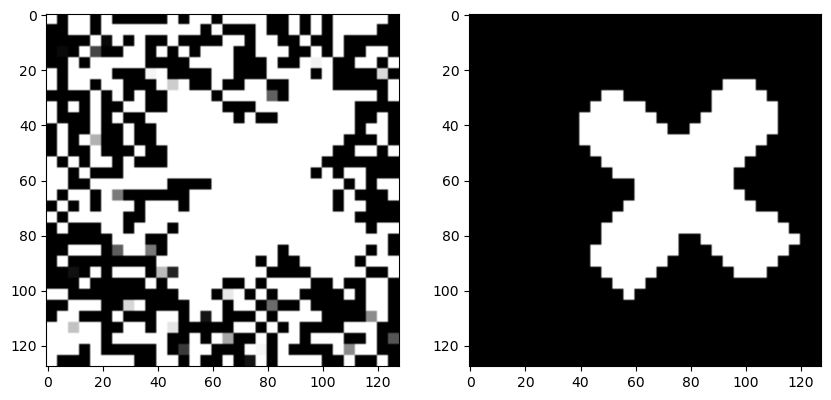

In [42]:
import random
figA, axsA = plt.subplots(1,2,figsize=(10,20)) 
r1 = random.randint(0, len(all_data)-1)  # extract a random image 
X, y = all_data[r1]["img"].to(device), all_data[r1]["mask"].to(device)
img1 = np.moveaxis(X.numpy(), 0, 2) # matplotlib requires 64x64x3 format
img2 = np.moveaxis(y.numpy(), 0, 2) # matplotlib requires 64x64x3 format
axsA[0].imshow(1-img1,cmap='Greys') 
axsA[1].imshow(1-img2,cmap='Greys')


Creaimo il modello Unet usando il modello predefinito su monai. Il modello monai si adatta automaticamente alle dimensioni dell'immagine di input. La rete UNet del monai è simile a quella standard con l’aggiunta di “Residual Unit” simili a quelle della ResNet, per ottenere la U-Net standard si pone num_res_unit=0. Questo modello, invece della Relu standard, usa la PRelu, che è una Relu dove la slope per i numeri negativi invece di essere fissa (=0) è determinata da un parametro che viene appreso durante il training. spatial_dims=2 indica che  elaboriamo immagini 2D. in_channels=1 indica che le immagini sono a singolo canale. out_channels=1 indica che eseguiamo una segmentazione binaria (potremmo fare una segmentazione multi-object). channels indica il numero di strati dei layer della U-Net  

In [21]:
# define model (UNet with residual units to automatically match input)
# 5 layer network with simple convolution/normalization/dropout/activation blocks defining the layers
U_Net = monai.networks.nets.UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2, 
)

Definiamo la funzione di loss, che qui sarà l'indice di Dice, e l'ottimizzatore. In un task di segmentazione la funzione loss deve essere una metrica di segmentazione, tipicamente si usa il multi-object DICE che collassa nel DICE standard nel caso di segmentazione binaria. Si utilizza il DICE perché pesa maggiormente l’oggetto da segmentare rispetto al background, cosa particolarmente utile quando si segmentano oggetti piccoli rispetto alle dimensioni dell’immagine. 

In [22]:
# define loss function (DICE)
loss_function = monai.losses.DiceLoss(sigmoid=True)
# define optimizer (ADAM)
optimizer = torch.optim.Adam(U_Net.parameters(), lr=LEARNING_RATE)

Come per la classificazione, definiamo la procedura di training che è analoga. La differenza è che nella segmentazione la loss viene calcolata tra due immagini e non tra due label in quanto il modello predice un'immagine.

In [25]:
# define training process

# define train procedure
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    
    train_loss = 0
    model.to(device)
    model.train() # put model in train mode
    
    # Add a loop to iter through training batches
    for batch in data_loader:
        # Send data to GPU
        X, y = batch["img"].to(device), batch["mask"].to(device)
       
        # Optimizer zero grad
        optimizer.zero_grad() 
       
        # Forward pass
        y_pred = model(X)
        
        # Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        
        # Loss backward
        loss.backward()
        
        # Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    #print(f"Train loss: {train_loss:.5f}")
    return train_loss

# The testing loop will be similar but it'll be called test_step() and it'll 
# take in a model, a DataLoader, a loss function and an evaluation function.

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              device: torch.device):
    
    test_loss = 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for batch in data_loader:
            # Send data to GPU
            X, y = batch["img"].to(device), batch["mask"].to(device)
            
            # Forward pass
            y_pred = model(X)
    
            # calcualte loss
            loss = loss_fn(y_pred, y)
            test_loss += loss.item()
            #test_acc += accuracy_fn(test_pred.argmax(dim=1), y).to(device)
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        #print(f"Test loss: {test_loss:.5f}%\n")
        return test_loss

# train loop
def train(device,
          model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          ):
  
    # Create results dictionary
    results = {"train_loss": [],"val_loss": []}

    # Loop through the training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        # Train step (on training data) 
        train_loss = train_step(model=model, 
                                       data_loader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)
        # Test step ( on validation data)
        val_loss = test_step(model=model, 
                                    data_loader=val_dataloader,
                                    loss_fn=loss_fn,device=device)
    
        # Print out what's happening
        print(f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f}  "
              )

        # Update the results dictionary
        results["train_loss"].append(train_loss)
        #results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        #results["val_acc"].append(val_acc)

      # Return the results dictionary
    return results

Addestriamo il modello

In [26]:
# perform training
model_results = train(device=device,
                      model=U_Net,
                      train_dataloader=train_dataloader,
                      val_dataloader=val_dataloader,
                      optimizer=optimizer,
                      loss_fn=loss_function,
                      epochs=15)

  7%|▋         | 1/15 [00:50<11:43, 50.28s/it]

Epoch: 1 | train_loss: 0.5154 | val_loss: 0.4613  


 13%|█▎        | 2/15 [01:15<07:42, 35.60s/it]

Epoch: 2 | train_loss: 0.4230 | val_loss: 0.3833  


 20%|██        | 3/15 [01:39<06:02, 30.24s/it]

...

Epoch: 13 | train_loss: 0.0287 | val_loss: 0.0340  


 93%|█████████▎| 14/15 [05:59<00:23, 23.92s/it]

Epoch: 14 | train_loss: 0.0258 | val_loss: 0.0347  


100%|██████████| 15/15 [06:22<00:00, 25.48s/it]

Epoch: 15 | train_loss: 0.0246 | val_loss: 0.0301  


Visualizziamo le curve di addestramento. Essendo l'ottimizzatore un minimizzatore la loss è definita come 1-Dice

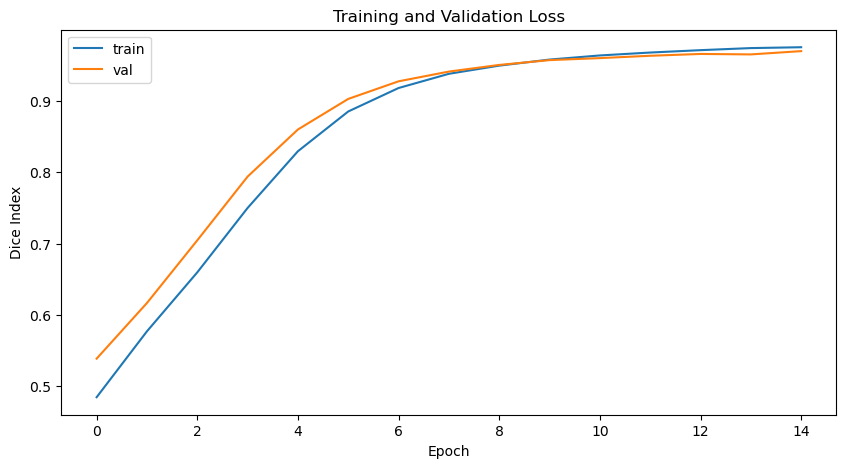

In [29]:
# plot training curves
np_train_loss = np.array([x for x in model_results['train_loss']])
np_val_loss = np.array([x for x in model_results['val_loss']])


plt.figure(figsize=(10,5))
plt.title("Training and Validation Loss")
plt.plot(1-np_train_loss,label="train")
plt.plot(1-np_val_loss,label="val")
plt.xlabel("Epoch")
plt.ylabel("Dice Index")
plt.legend()
plt.show()

Misuriamo la qualità della segmentazione (cioè il Dice Index e lo Jaccard index) sul train, validation e test set. Come nella classificazione, l'uscita della U-Net non è binaria (0-1) per motivi computazionali, quindi la dobbiamo ricondurre in un formato compatibile con le maschere reference. 

In [35]:
# evaluate results
from monai.metrics import DiceMetric,MeanIoU

dice_metric = DiceMetric(include_background=True, reduction="mean_batch", get_not_nans=False)

IoU_metric = MeanIoU(include_background=True, reduction="mean_batch", get_not_nans=False)


# define transformation from scores to binary classification
post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

U_Net.eval()

# compute training set DICE index
with torch.inference_mode():
    for batch in train_dataloader:
        X, y = batch["img"].to(device), batch["mask"].to(device)
        y_pred = U_Net(X)
        y_id =  post_trans(y_pred)   
        dice_metric(y_pred=y_id, y=y)
        IoU_metric(y_pred=y_id, y=y)

    dcs = dice_metric.aggregate().item()   
    IoU = IoU_metric.aggregate().item()   
    
    dice_metric.reset()
    IoU_metric.reset()
    
    print(f"Training Set DICE: {dcs:.3f} ")   
    print(f"Training Set Jaccard: {IoU:.3f} ")   

# compute validation set DICE index
with torch.inference_mode():
    for batch in val_dataloader:
        X, y = batch["img"].to(device), batch["mask"].to(device)
        y_pred = U_Net(X)
        y_id =  post_trans(y_pred)   
        dice_metric(y_pred=y_id, y=y)
        IoU_metric(y_pred=y_id, y=y)
        
    dcs = dice_metric.aggregate().item()   
    IoU = IoU_metric.aggregate().item() 
    dice_metric.reset()
    IoU_metric.reset()
    print(f"Validation Set DICE: {dcs:.3f} ")   
    print(f"Validation Set Jaccard: {IoU:.3f} ")   
    

# compute test set DICE index
with torch.inference_mode():
    for batch in test_dataloader:
        X, y = batch["img"].to(device), batch["mask"].to(device)
        y_pred = U_Net(X)
        y_id =  post_trans(y_pred)   
        dice_metric(y_pred=y_id, y=y)
        IoU_metric(y_pred=y_id, y=y)
        
    dcs = dice_metric.aggregate().item()   
    IoU = IoU_metric.aggregate().item() 
    dice_metric.reset()
    IoU_metric.reset()
    print(f"Test Set DICE: {dcs:.3f} ")  
    print(f"Test Set Jaccard: {IoU:.3f} ")   

Training Set DICE: 0.985 
Training Set Jaccard: 0.970 
Validation Set DICE: 0.976 
Validation Set Jaccard: 0.954 
Test Set DICE: 0.974 
Test Set Jaccard: 0.949 


Visualizziamo alcuni risultati. Confrontiamo le maschere predette con le maschere reference attraverso l'image fusion con tecnica RGB.

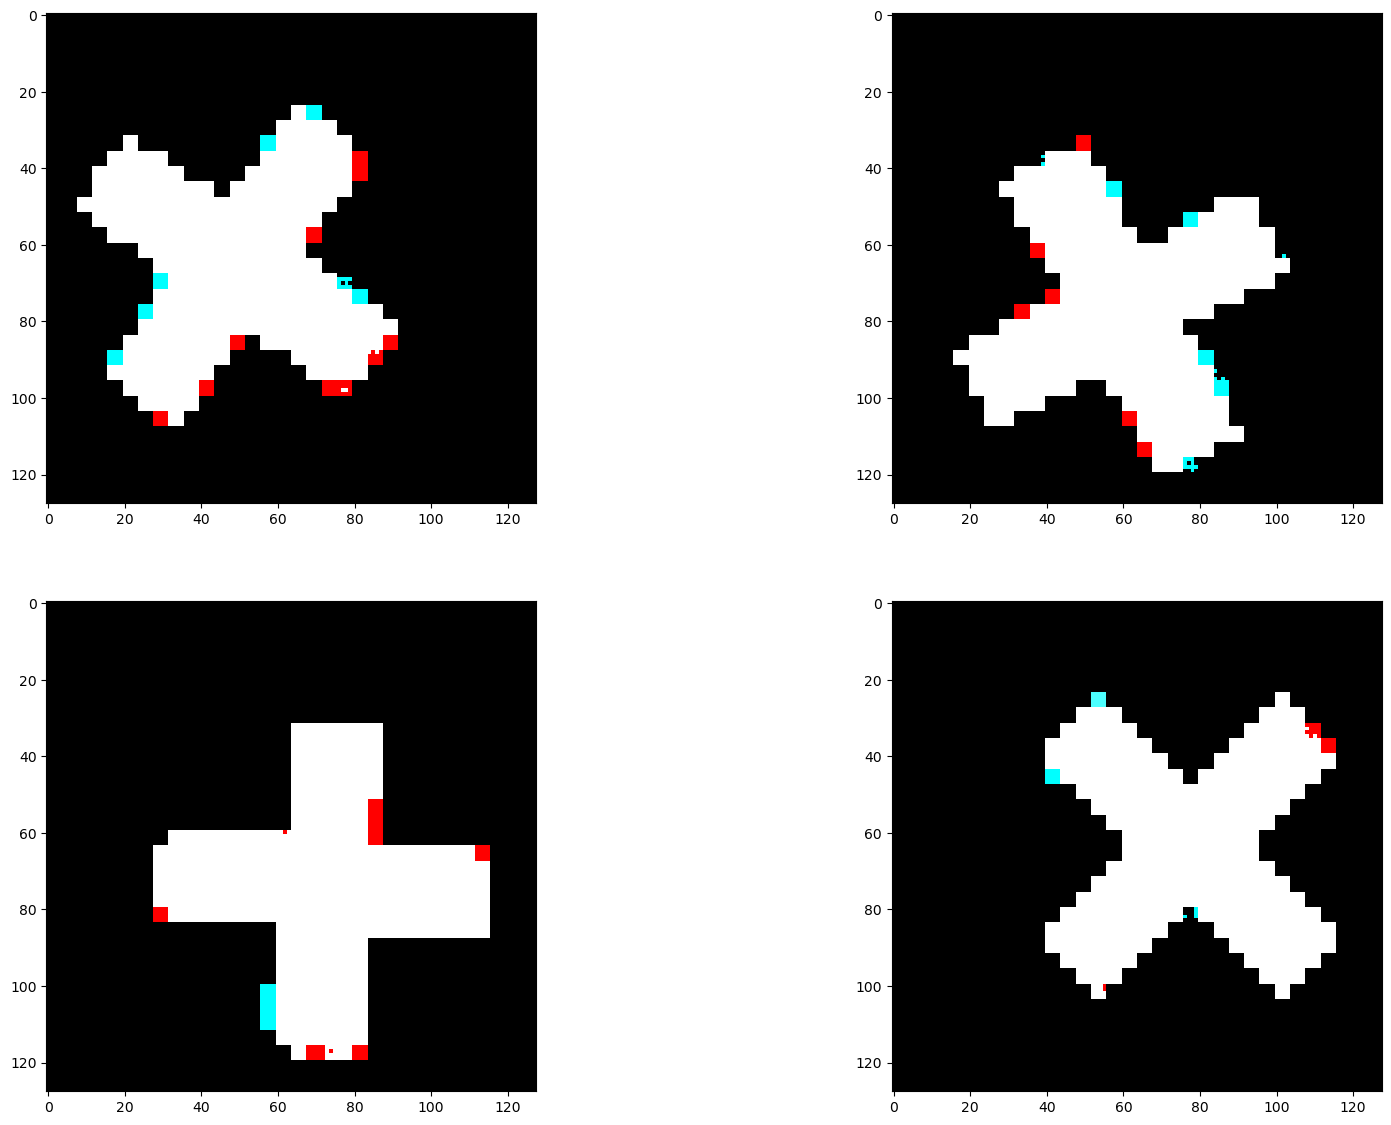

In [38]:
# display some images

import random
dimX=2
dimY=2

figB, axsB = plt.subplots(dimX,dimY,figsize=(20,14)) 
for i in range(dimX):
    for j in range(dimY):
        r1 = random.randint(0, len(test_dataset)-1)  # extract a random image from test set
        X, y = test_dataset[r1]["img"].to(device), test_dataset[r1]["mask"].to(device)
        U_Net.eval()
        y_pred = U_Net(X.unsqueeze(0))
        y_id =  post_trans(y_pred.squeeze(0))  
        img = np.zeros([y.shape[1],y.shape[2],3])
        img[:,:,0]=np.squeeze(y.cpu())
        img[:,:,1]=np.squeeze(y_id.cpu())
        img[:,:,2]=np.squeeze(y_id.cpu())
        
        #axsB[i,j].imshow(np.squeeze(y.cpu()),cmap='Greys')  # blending
        #axsB[i,j].imshow(np.squeeze(y_id.cpu()),alpha=0.5,cmap='Greys')
        axsB[i,j].imshow(img,cmap='Greys') # RGB